In [40]:
import scanpy as sc
import decoupler as dc
import pertpy as pt


sc.set_figure_params(figsize=(3, 3), frameon=False)

In [41]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_with_raw.h5ad')

In [42]:
adata.X = adata.layers['counts']
adata.X = adata.X.astype(int)

In [43]:
adata = adata[adata.obs.cell_class.str.contains('ligo')]
adata = adata[~adata.obs.cell_class.str.contains('mic')]

In [ ]:
adata.obs_names_make_unique()

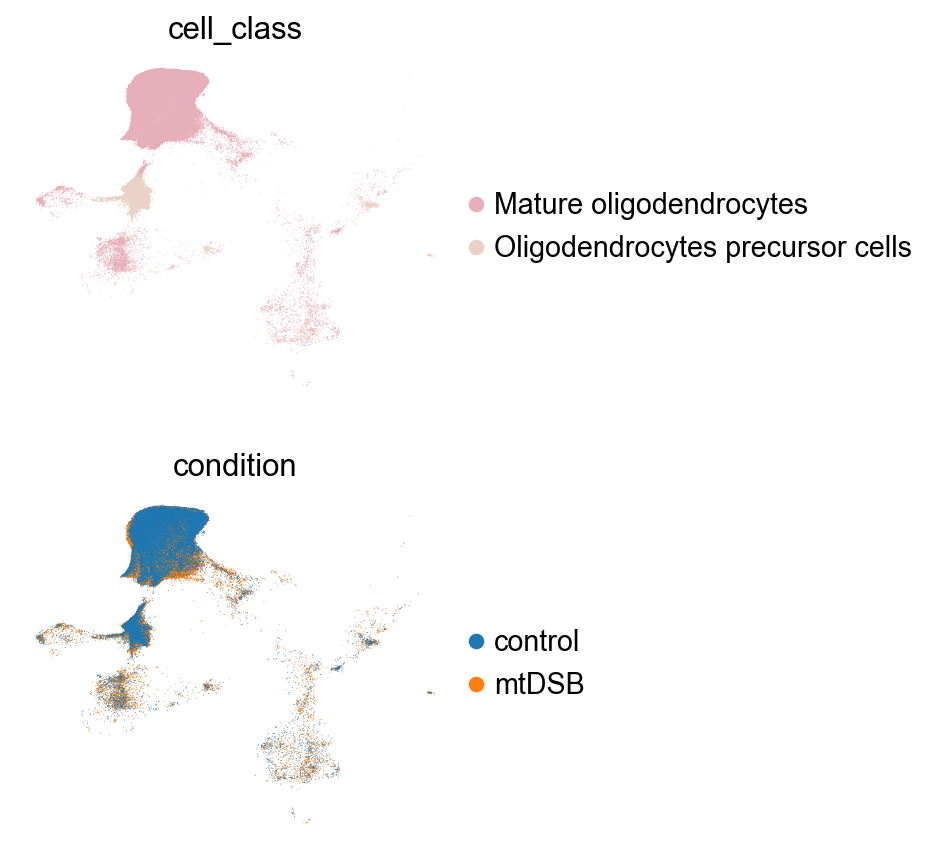

In [44]:
sc.pl.umap(adata, color=["cell_class", "condition"], ncols=1)

## Pseudobulking
The pseudo-bulk approach involves the following steps:

Subsetting the cell type of interest
Extracting their raw integer counts
Summing their counts per gene into a single profile if they pass quality control
Then, DEA can be performed if there are at least two biological replicates per condition (more replicates are recommended).

Pseudobulking can easily be performed using the function {func}decoupler.pp.pseudobulk. In this example, the counts are just summed, though other modes such as the mean or any custom aggregation function are available. For more information, refer to the mode argument.

In [45]:
pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col="sample_id",
    groups_col="cell_class",
    mode="sum",
)

In [46]:
pdata.obs["age"]

RB4282_Mature oligodendrocytes             60
RB4350_Mature oligodendrocytes             60
RB4401_Mature oligodendrocytes             60
RB4403_Mature oligodendrocytes             60
RB4405_Mature oligodendrocytes             60
RB4498_Mature oligodendrocytes             60
RB4620_Mature oligodendrocytes             21
RB4627_Mature oligodendrocytes             21
RB4630_Mature oligodendrocytes             21
RB4653_Mature oligodendrocytes             21
RB4658_Mature oligodendrocytes             21
RB4676_Mature oligodendrocytes             21
RB4282_Oligodendrocytes precursor cells    60
RB4350_Oligodendrocytes precursor cells    60
RB4401_Oligodendrocytes precursor cells    60
RB4403_Oligodendrocytes precursor cells    60
RB4405_Oligodendrocytes precursor cells    60
RB4498_Oligodendrocytes precursor cells    60
RB4620_Oligodendrocytes precursor cells    21
RB4627_Oligodendrocytes precursor cells    21
RB4630_Oligodendrocytes precursor cells    21
RB4653_Oligodendrocytes precursor 

In [47]:
# make sure these are in pdata.obs (one row = one biological sample / pseudobulk)
pdata.obs["condition"] = pdata.obs["condition"].astype("category")   # e.g. ["control","mtDSB"]
pdata.obs["condition"] = pdata.obs["condition"].cat.reorder_categories(["control","mtDSB"], ordered=True)

# age as categorical (p21/p60)
pdata.obs["age"] = pdata.obs["age"].astype("category")       # e.g. ["p21","p60"]
pdata.obs["age"] = pdata.obs["age"].cat.reorder_categories(["21","60"], ordered=True)

# OR age as continuous (if you have numeric ages)
if "age" in pdata.obs:
    pdata.obs["age"] = pdata.obs["age"].astype(float)
    pdata.obs["age_z"] = (pdata.obs["age"] - pdata.obs["age"].mean()) / pdata.obs["age"].std()

In [48]:
# Store raw counts in layers
pdata.layers["counts"] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata, key="counts", inplace=True)

In [49]:
import warnings
warnings.filterwarnings("ignore")

In [50]:
pdata.obs["age"] = (
    pdata.obs["age"]
    .astype(str)
    .replace({"21.0": "p21", "60.0": "p60"})
    .astype("category")
    .cat.reorder_categories(["p21","p60"], ordered=True)
)

In [51]:
pdata.obs["age"] = pdata.obs["age"].astype(str)          # convert numbers → strings
pdata.obs["age"] = pdata.obs["age"].astype("category")   # convert → categorical
pdata.obs["age"] = pdata.obs["age"].cat.reorder_categories(["p21","p60"], ordered=True)

In [52]:
cols = pds.formulaic_contrasts.design_matrix.model_spec.column_names
print(cols)

('Intercept', 'age[T.p60]', 'condition[T.mtDSB]', 'age[T.p60]:condition[T.mtDSB]')


In [53]:
import pertpy as pt

pds = pt.tl.PyDESeq2(adata=pdata, design="~ age + condition", layer="counts")  # drop layer=... if X has counts
pds.fit()

# condition effect (mtDSB vs control), adjusted for age
res_df = pds.test_contrasts(pds.contrast(column="condition", baseline="control", group_to_compare="mtDSB"))


Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.16 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.13 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 0. 1.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Tnfsf9       8.968082        0.481949  0.223215  2.159120  0.030841  0.999956
Adcy1     1905.902120       -0.049680  0.092515 -0.536992  0.591273  0.999956
Atp6v0d2     1.444564        2.123593  0.750416  2.829887  0.004656  0.628854
Dnm1l     2223.004411        0.028190  0.025051  1.125320  0.260454  0.999956
S100b     1048.507367       -0.070741  0.102510 -0.690087  0.490139  0.999956
...               ...             ...       ...       ...       ...       ...
Prf1         0.702082        0.502800  0.597884  0.840965  0.400367  0.999956
Emsy       615.470314       -0.038182  0.050411 -0.757427  0.448794  0.999956
Icam1       14.653530       -0.048227  0.288688 -0.167056  0.867326  0.999956
Gldc       108.489057       -0.070322  0.245057 -0.286961  0.774142  0.999956
Atp4a       28.922076       -0.171426  0.461272 -0.371637  0.710163  0.99995

... done in 0.11 seconds.



In [54]:
# 1️⃣ condition effect (mtDSB vs control)
res_condition = pds.test_contrasts(
    pds.contrast(column="condition", baseline="control", group_to_compare="mtDSB")
)

# 2️⃣ age effect (60 vs 21)
# NOTE: use the exact strings that exist in your pdata.obs['age'] column (likely "21.0" / "60.0")
res_age = pds.test_contrasts(
    pds.contrast(column="age", baseline="p21", group_to_compare="p60")
)

# 3️⃣ interaction (does mtDSB effect differ by age)
# model with interaction
pds = pt.tl.PyDESeq2(adata=pdata, design="~ age * condition", layer="counts")
pds.fit()

res_df = pds.test_contrasts(
    pds.contrast(column="condition", baseline="control", group_to_compare="mtDSB")
)
import numpy as np

# the exact column names in your model
cols = pds.formulaic_contrasts.design_matrix.model_spec.column_names
print(cols)
# ('Intercept', 'age[T.p60]', 'condition[T.mtDSB]', 'age[T.p60]:condition[T.mtDSB]')

# build the contrast vector for the interaction term
contrast_vector = np.zeros(len(cols))
contrast_vector[cols.index('age[T.p60]:condition[T.mtDSB]')] = 1
print(contrast_vector)  # should now show [0., 0., 0., 1.]

# run the test
res_interaction = pds.test_contrasts(contrast_vector)
res_interaction.head()

Running Wald tests...
... done in 0.12 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 0. 1.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Tnfsf9       8.968082        0.481949  0.223215  2.159120  0.030841  0.999956
Adcy1     1905.902120       -0.049680  0.092515 -0.536992  0.591273  0.999956
Atp6v0d2     1.444564        2.123593  0.750416  2.829887  0.004656  0.628854
Dnm1l     2223.004411        0.028190  0.025051  1.125320  0.260454  0.999956
S100b     1048.507367       -0.070741  0.102510 -0.690087  0.490139  0.999956
...               ...             ...       ...       ...       ...       ...
Prf1         0.702082        0.502800  0.597884  0.840965  0.400367  0.999956
Emsy       615.470314       -0.038182  0.050411 -0.757427  0.448794  0.999956
Icam1       14.653530       -0.048227  0.288688 -0.167056  0.867326  0.999956
Gldc       108.489057       -0.070322  0.245057 -0.286961  0.774142  0.999956
Atp4a       28.922076       -0.171426  0.461272 -0.371637  0.710163  0.99995

... done in 0.11 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.16 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.22 seconds.

Fitting LFCs...
... done in 0.13 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 0. 1. 0.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Tnfsf9       8.968082        0.442608  0.359563  1.230961  0.218338  0.999975
Adcy1     1905.902120        0.048966  0.130564  0.375032  0.707637  0.999975
Atp6v0d2     1.444564        1.415264  1.223666  1.156577  0.247445  0.999975
Dnm1l     2223.004411        0.085671  0.031814  2.692880  0.007084  0.999975
S100b     1048.507367       -0.214306  0.141351 -1.516129  0.129487  0.999975
...               ...             ...       ...       ...       ...       ...
Prf1         0.702082       -0.376756  1.081581 -0.348338  0.727586  0.999975
Emsy       615.470314        0.000318  0.074043  0.004301  0.996568  0.999975
Icam1       14.653530       -0.413651  0.435089 -0.950728  0.341743  0.999975
Gldc       108.489057       -0.165306  0.355277 -0.465288  0.641726  0.999975
Atp4a       28.922076       -0.218463  0.664950 -0.328540  0.742504  0.99

... done in 0.12 seconds.

Running Wald tests...
... done in 0.12 seconds.



,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,Hcrt,98.980556,-8.438217,1.149551,-7.340445,2.128848e-13,1.085500e-09,None
1,Pmch,292.710899,-6.010215,1.038901,-5.785167,7.244040e-09,1.846868e-05,None
2,Chrm2,113.828046,0.945781,0.233865,4.044125,5.251896e-05,7.994660e-02,None
3,Agrp,7.321506,-6.099417,1.523958,-4.002353,6.271551e-05,7.994660e-02,None
4,Epha4,258.887050,-0.509519,0.131994,-3.860167,1.133095e-04,1.155530e-01,None


In [74]:
res_interaction.T['Ldhb']

baseMean       6747.683714
log_fc             0.02928
lfcSE             0.117627
stat               0.24892
p_value           0.803423
adj_p_value       0.999976
contrast              None
Name: Ldhb, dtype: object

In [56]:
res_interaction = res_interaction.set_index('variable')

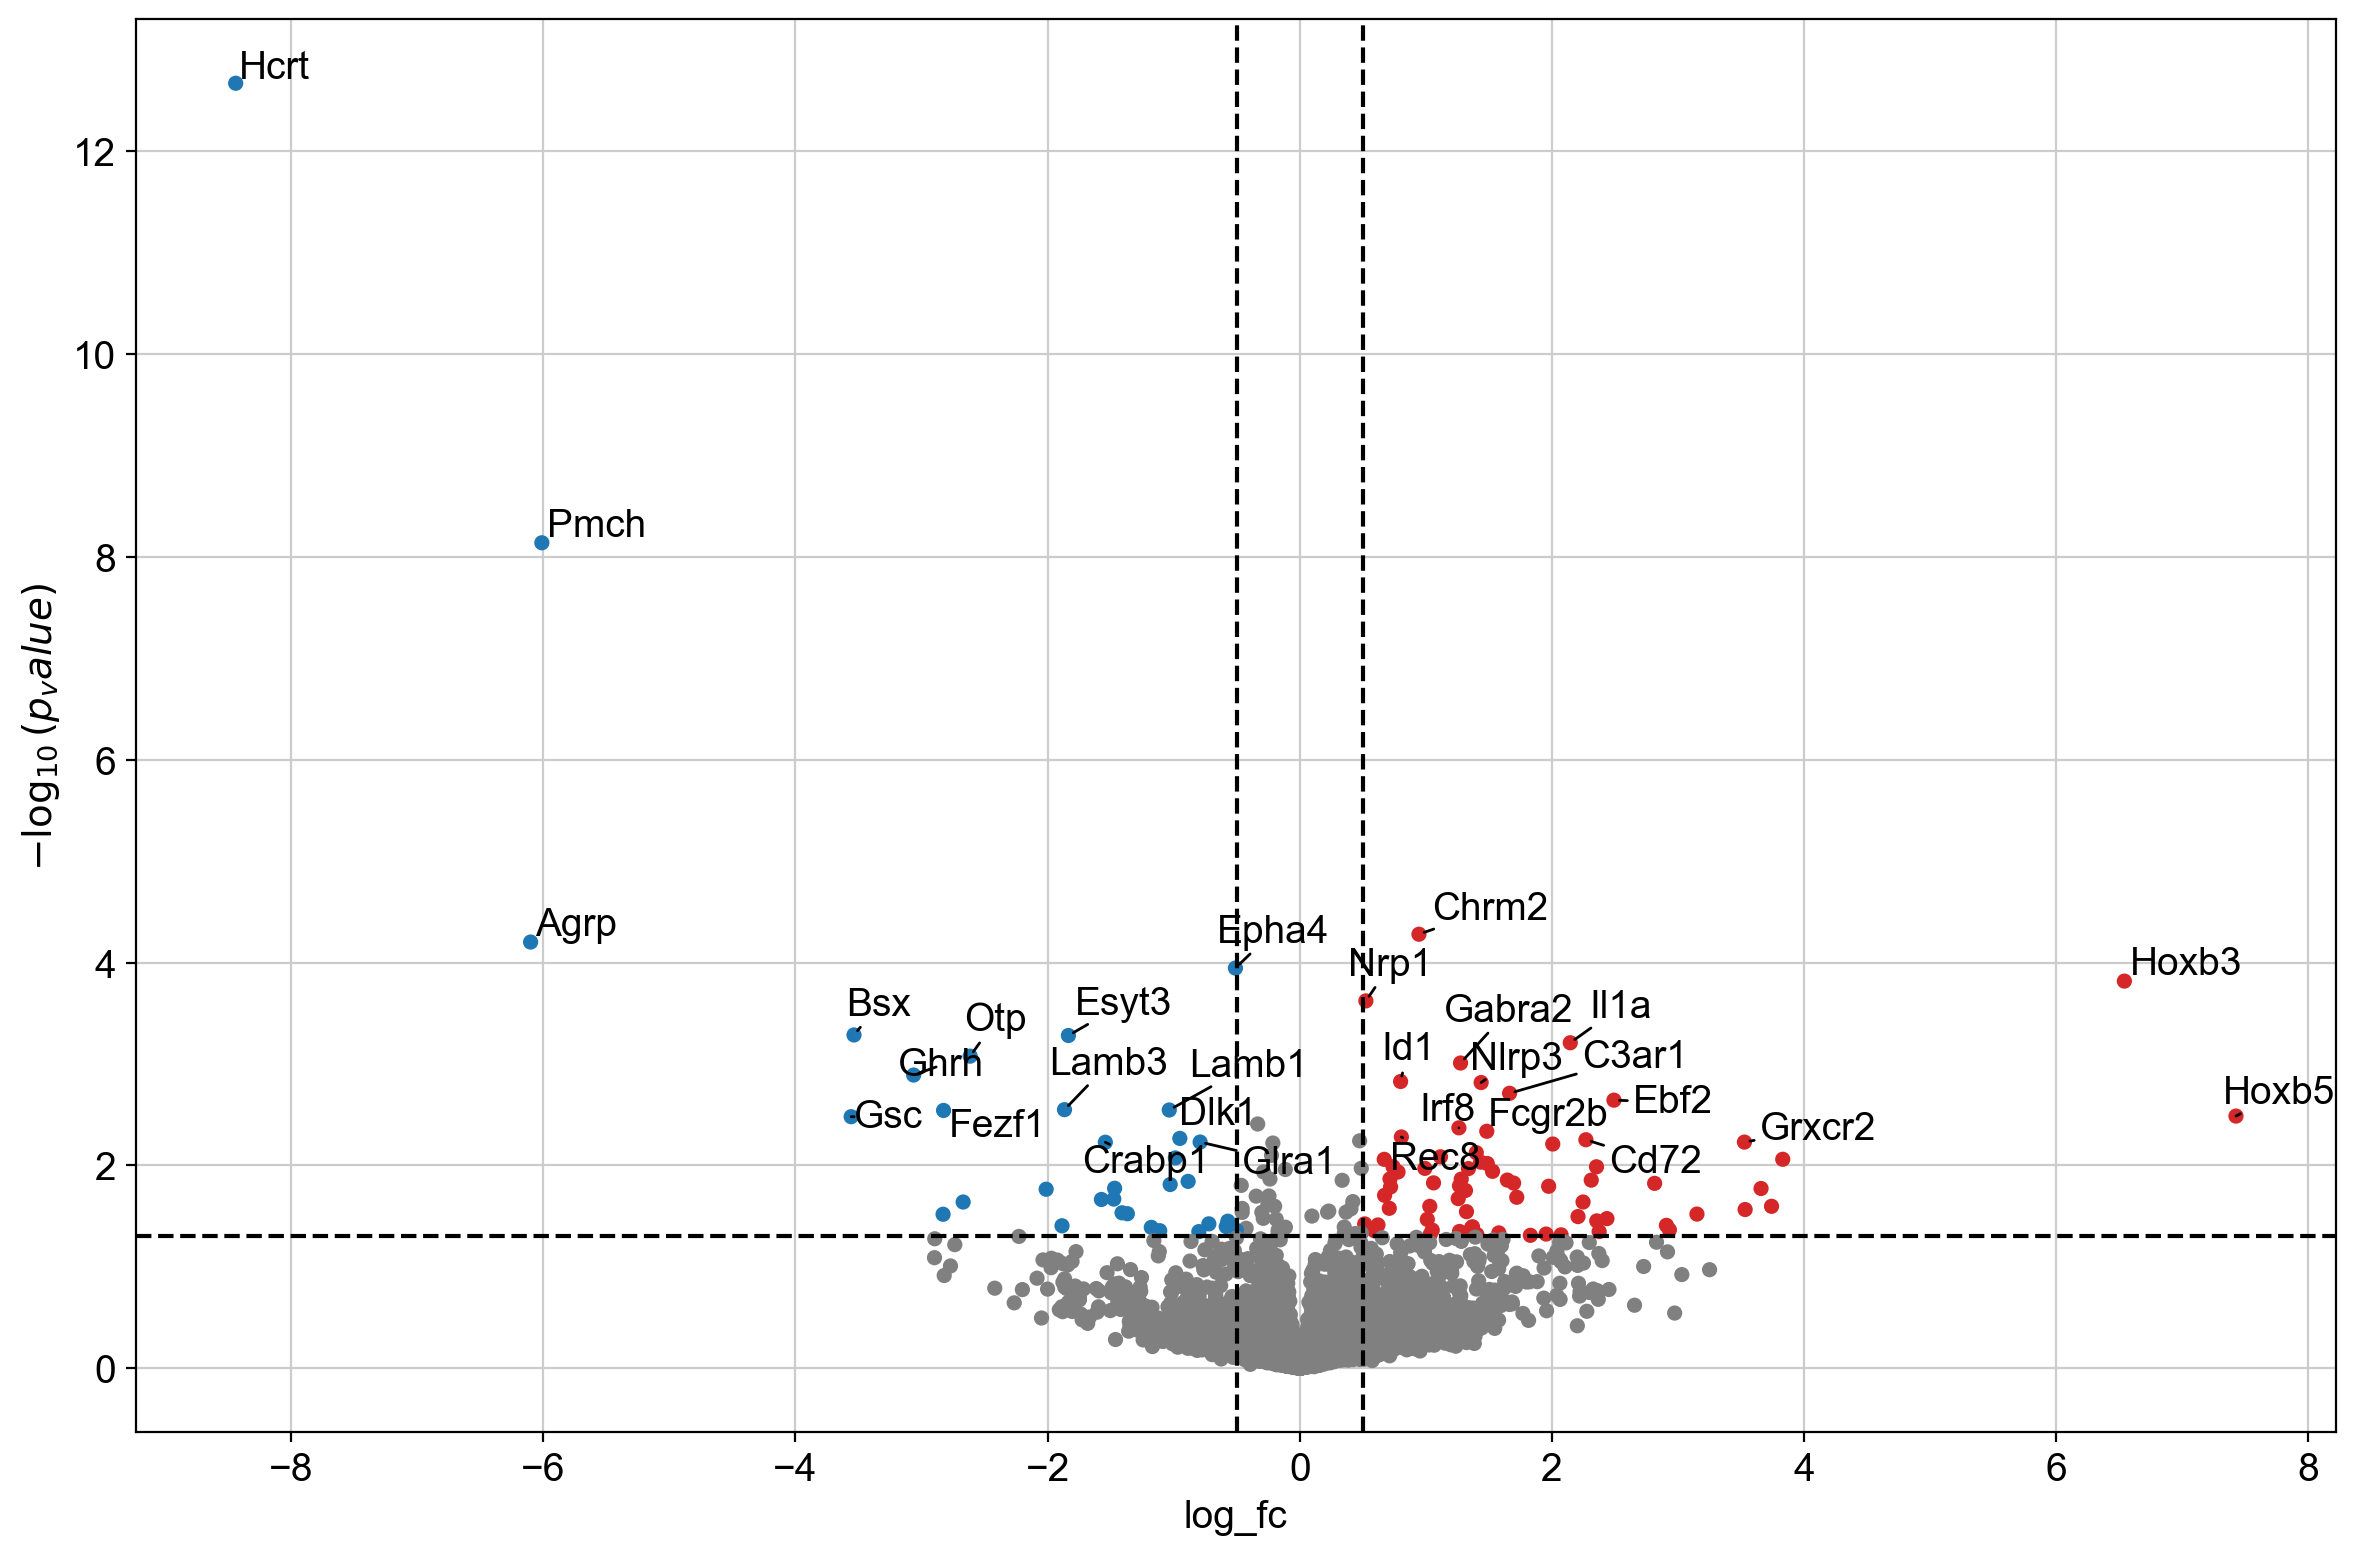

In [57]:
import matplotlib.pyplot as plt
import decoupler as dc

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 6)    
dc.pl.volcano(
        res_interaction,
        x="log_fc",
        y="p_value",
        top=30,
    figsize=(12, 8)
    )

# 🧬 Biological narrative

“In oligodendrocytes, mtDNA double-strand breaks elicit an age-dependent transcriptional remodeling.
At p21, the mtDSB response engages developmental regulators and neuropeptide-like programs, whereas at p60 it shifts toward inflammatory and dedifferentiation-associated genes (Irf8, Il1a, Hoxb3, Fcgr2b).
This suggests that aging transforms the oligodendrocyte mtDNA-damage response from a regenerative to a stress-reactive state.”